In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sharankumare/mcq-sample/sample_submission.csv
/kaggle/input/datasets/sharankumare/mcq-test/test.csv
/kaggle/input/datasets/sharankumare/mcq-train/train.csv


In [2]:
import random
import numpy as np
import torch

SEED = 8

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
import wandb

wandb.login(key="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")

wandb.init(
    project="24f3004935-t22026",
    name = 'roberta_lr_3e5_ep4_run2'
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 24f3004935 (24f3004935-dl-genai-project) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run b9hp9mkk
wandb: Tracking run with wandb version 0.26.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260724_080033-b9hp9mkk
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run roberta_lr_3e5_ep4_run2
wandb: ⭐️ View project at https://wandb.ai/24f3004935-dl-genai-project/24f3004935-t22026
wandb: 🚀 View run at https://wandb.ai/24f3004935-dl-genai-project/24f3004935-t22026/runs/b9hp9mkk


In [4]:
Train = pd.read_csv("/kaggle/input/datasets/sharankumare/mcq-train/train.csv")
test = pd.read_csv("/kaggle/input/datasets/sharankumare/mcq-test/test.csv")
sample = pd.read_csv("/kaggle/input/datasets/sharankumare/mcq-sample/sample_submission.csv")

print(Train.shape)
print(test.shape)

Train.head()

(2000, 8)
(500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [5]:
Train["text"] = (
    "Question: " + Train["prompt"].fillna("") +
    " A: " + Train["A"].fillna("") +
    " B: " + Train["B"].fillna("") +
    " C: " + Train["C"].fillna("") +
    " D: " + Train["D"].fillna("") +
    " E: " + Train["E"].fillna("")
)

test["text"] = (
    "Question: " + test["prompt"].fillna("") +
    " A: " + test["A"].fillna("") +
    " B: " + test["B"].fillna("") +
    " C: " + test["C"].fillna("") +
    " D: " + test["D"].fillna("") +
    " E: " + test["E"].fillna("")
)

In [6]:
label2id = {
    "A":0,
    "B":1,
    "C":2,
    "D":3,
    "E":4
}

id2label = {v:k for k,v in label2id.items()}

Train["label"] = Train["answer"].map(label2id)

In [7]:
Train_cleaned = Train.drop_duplicates(subset=["prompt"]).copy()

Train = Train_cleaned.sample(frac=1.0, random_state=42).reset_index(drop=True)

### Train Test split

In [8]:
from sklearn.model_selection import train_test_split

train, val = train_test_split(
    Train,
    test_size=0.2,
    random_state=42,
    stratify=Train["answer"]
)

In [9]:
Train.head(2)

,id,prompt,A,B,C,D,E,answer,text,label
0,1233,Identify the correct statement: What is the se...,The second law of thermodynamics is a physical...,The second law of thermodynamics is a physical...,The second law of thermodynamics is a physical...,The second law of thermodynamics is a physical...,The second law of thermodynamics is a physical...,E,Question: Identify the correct statement: What...,4
1,1118,Pick the best possible answer: What is the sig...,The high degree of fatty-acyl disorder in the ...,The high degree of fatty-acyl disorder in the ...,The high degree of fatty-acyl disorder in the ...,The high degree of fatty-acyl disorder in the ...,The high degree of fatty-acyl disorder in the ...,C,Question: Pick the best possible answer: What ...,2


In [10]:
val.head(2)

,id,prompt,A,B,C,D,E,answer,text,label
549,180,What is the Kutta condition?,The Kutta condition is a physical requirement ...,The Kutta condition is a physical requirement ...,The Kutta condition is a mathematical requirem...,The Kutta condition is a mathematical requirem...,The Kutta condition is a physical requirement ...,A,Question: What is the Kutta condition? A: The ...,0
1054,414,Which of the following is correct? What is the...,The complete electromagnetic Hamiltonian of an...,The complete electromagnetic Hamiltonian of an...,The complete electromagnetic Hamiltonian of an...,The complete electromagnetic Hamiltonian of an...,The complete electromagnetic Hamiltonian of an...,D,Question: Which of the following is correct? W...,3


# PRE-TRAINED MODEL

In [11]:
from transformers import AutoTokenizer

MODEL = "FacebookAI/roberta-large"

tokenizer = AutoTokenizer.from_pretrained(MODEL)

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    
    # Predictions for Accuracy and F1 (Top 1)
    preds = logits.argmax(axis=-1)
    
    # Top 3 Predictions for MAP@3
    top_3_preds = np.argsort(-logits, axis=-1)[:, :3] 
    
    # Calculate MAP@3 manually
    map_at_3_scores = []
    for label, top_3 in zip(labels, top_3_preds):
        score = 0.0
        for rank, pred in enumerate(top_3):
            if pred == label:
                score = 1.0 / (rank + 1)
                break
        map_at_3_scores.append(score)
        
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "map_at_3": np.mean(map_at_3_scores)
    }


In [13]:
from datasets import Dataset

# Hugging Face datasets
train_ds = Dataset.from_pandas(
    train[["text", "label"]]
)

val_ds = Dataset.from_pandas(
    val[["text", "label"]]
)

test_ds = Dataset.from_pandas(
    test[["text"]]
)

In [14]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize , batched=True)
test_ds = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/1406 [00:00<?, ? examples/s]

Map:   0%|          | 0/352 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [15]:
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

model_1 = AutoModelForSequenceClassification.from_pretrained(
    MODEL,
    num_labels=5
)

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [16]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,
    per_device_train_batch_size=8,
    learning_rate=3e-5,
    weight_decay=0.05,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss", 
    greater_is_better=False,           
    save_strategy="epoch",
    eval_strategy="epoch",             
    save_total_limit=2,
    seed=42,
    data_seed=42,
    report_to="wandb",
    run_name = 'roberta_lr3e5_ep4_run2'
)


In [17]:
# Initializing the Trainer 
trainer = Trainer(
    model=model_1,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

# training loop 
trainer.train()

print("\nExtracting final model predictions...")
val_output = trainer.predict(val_ds)
val_results = val_output.metrics
val_preds = val_output.predictions.argmax(axis=-1)
val_labels = val_output.label_ids

# Subset of 1000 rows for the training confusion matrix
train_sample = train_ds.select(range(min(1000, len(train_ds))))
train_output = trainer.predict(train_sample)
train_results = train_output.metrics
train_preds = train_output.predictions.argmax(axis=-1)
train_labels = train_output.label_ids

# Print clear side-by-side performance summary table
print("\n" + "="*50)
print("          FINAL MODEL PERFORMANCE COMPARISON          ")
print("="*50)
print(f"TRAIN MAP@3:      {train_results.get('test_map_at_3', 0.0):.4f}  |  VAL MAP@3:      {val_results.get('test_map_at_3', 0.0):.4f}")
print(f"TRAIN Accuracy:   {train_results.get('test_accuracy', 0.0):.4f}  |  VAL Accuracy:   {val_results.get('test_accuracy', 0.0):.4f}")
print(f"TRAIN F1 Macro:   {train_results.get('test_f1_macro', 0.0):.4f}  |  VAL F1 Macro:   {val_results.get('test_f1_macro', 0.0):.4f}")
print("="*50)

# Save the final submission artifacts cleanly
trainer.save_model("./best_submission_model")
tokenizer.save_pretrained("./best_submission_model")
print("\nArtifacts locked down in folder: './best_submission_model'\n")


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Map At 3
1,3.246080,3.137692,0.269886,0.147708,0.449811
2,1.861056,0.225680,0.974432,0.974623,0.985322
3,0.086647,0.001202,1.000000,1.000000,1.000000
4,0.001218,0.000565,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Extracting final model predictions...



          FINAL MODEL PERFORMANCE COMPARISON          
TRAIN MAP@3:      1.0000  |  VAL MAP@3:      1.0000
TRAIN Accuracy:   1.0000  |  VAL Accuracy:   1.0000
TRAIN F1 Macro:   1.0000  |  VAL F1 Macro:   1.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Artifacts locked down in folder: './best_submission_model'



In [18]:
import shutil

shutil.make_archive(
    "/kaggle/working/best_submission_model",  # Output ZIP
    "zip",
    "/kaggle/working/best_submission_model"   # Folder to zip
)

print("ZIP created successfully!")

ZIP created successfully!


In [19]:
!ls -lh /kaggle/working/best_submission_model.zip

-rw-r--r-- 1 root root 1.2G Jul 24 08:23 /kaggle/working/best_submission_model.zip


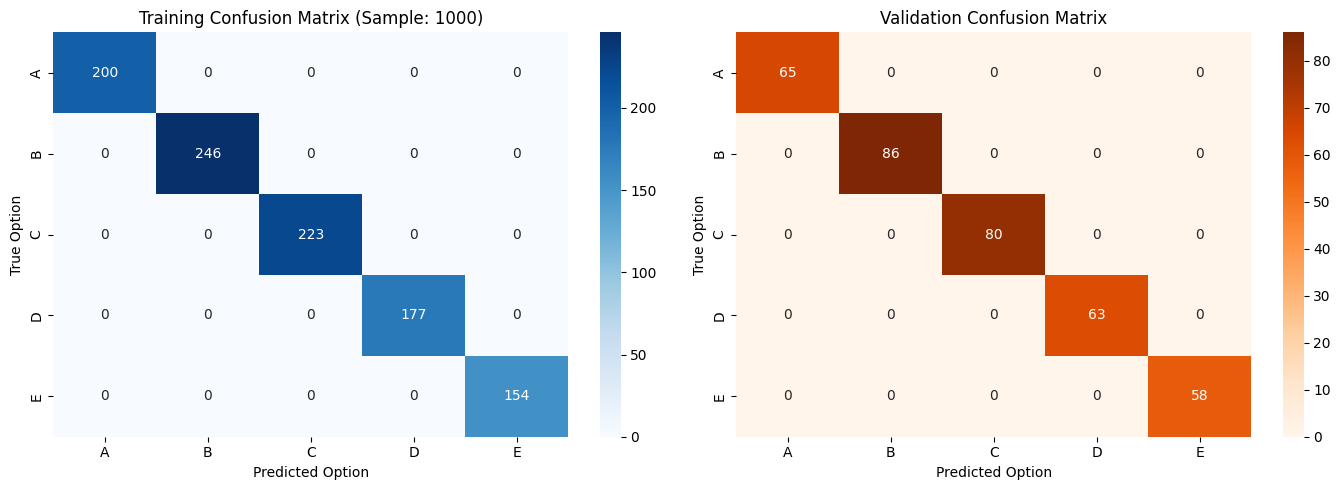

In [20]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_train = confusion_matrix(train_labels, train_preds)
cm_val = confusion_matrix(val_labels, val_preds)
class_names = ['A', 'B', 'C', 'D', 'E']

# Create subplots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Train 
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title(f'Training Confusion Matrix (Sample: {len(train_sample)})')
axes[0].set_xlabel('Predicted Option')
axes[0].set_ylabel('True Option')

# Plot Validation 
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Option')
axes[1].set_ylabel('True Option')

plt.tight_layout()
plt.show()


## TOP 3 PREDICTIONS

In [21]:
import numpy as np
import torch

pred = trainer.predict(test_ds)

probs = torch.softmax(
    torch.tensor(pred.predictions),
    dim=1
).numpy()

pretrained_predictions = []

for p in probs:
    top3 = np.argsort(p)[::-1][:3]
    pretrained_predictions.append(
        " ".join(id2label[i] for i in top3)
    )



## SUBMISSION

In [22]:
submission = pd.DataFrame({
    "id": test["id"],
    "Prediction": pretrained_predictions
})

submission.to_csv("submission.csv",index=False)

submission.head()

import wandb

wandb.finish()
print("W&B run closed.")

wandb: updating run metadata
wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading history steps 14-14, summary
wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁███
wandb:           eval/f1_macro ▁███
wandb:               eval/loss █▂▁▁
wandb:           eval/map_at_3 ▁███
wandb:            eval/runtime ▁▇▇█
wandb: eval/samples_per_second █▂▂▁
wandb:   eval/steps_per_second █▁▁▁
wandb:           test/accuracy ▁▁
wandb:           test/f1_macro ▁▁
wandb:               test/loss █▁
wandb:                      +9 ...
wandb: 
wandb: Run summary:
wandb:           eval/accuracy 1
wandb:           eval/f1_macro 1
wandb:               eval/loss 0.00057
wandb:           eval/map_at_3 1
wandb:            eval/runtime 21.3473
wandb: eval/samples_per_second 16.489
wandb:   eval/steps_per_second 1.031
wandb:           test/accuracy 1
wandb:           test/f1_macro 1
wandb:               test/loss 0.00055
wandb:                     +14 ...
wandb: 

W&B run closed.
